# Exploratory Data Analysis Notebook

The EDA Notebook provides a descriptive exploration of the cleaned ride-sharing dataset. The main focuses of its examination are: 

- variable distributions
- category frequencies
- preliminary patterns involving historical ride cost

Detailed demand-and-supply analysis, pricing-factor evaluation, and predictive modelling are completed separately by other team members.

While developing the notebook, the questions that guided the analysis were:

1. Which ride characteristics show the clearest relationship with historical ride cost?

2. How does historical ride cost differ across vehicle types, locations, booking times and customer loyalty groups, and does the vehicle-type difference remain visible across different ride-duration groups?

## Import Libraries and Create Main Functions

Importing the libraries needed for data analysis and visualization

In [379]:
import pandas as pd 
import matplotlib.pyplot as plt 
import os 

The main goal of the following function is to create consistent bar charts for categorical comparisons. 
It receives the data, chart title, and axis labels, then displays the categories and their corresponding values

In [380]:
def plot_bar_chart(series, title, xlabel, ylabel):
    plt.figure(figsize=(7, 4))
    plt.bar(series.index, series.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

The main goal of the following function is to group the dataset by a selected categorical variable and calculates the number of observations, mean historical ride cost, and median historical ride cost for each category

In [381]:
def summarise_cost_by_category(dataframe, category):
    return (dataframe.groupby(category)["Historical_Cost_of_Ride"].agg(["count", "mean", "median"]).round(2))

## Load Cleaned Dataset

Loading the cleaned dataset that was saved during the data cleaning step

In [382]:
cleaned_file_path = "../Data/Cleaned/cleaned_dynamic_pricing.csv"

if os.path.exists(cleaned_file_path):
    df = pd.read_csv(cleaned_file_path)
    print("Cleaned dataset loaded successfully.")
else:
    raise FileNotFoundError("The cleaned dataset could not be found.")

df.head()

Cleaned dataset loaded successfully.


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


## Dataset Overview

The main goal of this section is to check the size of the cleaned dataset and review the main summary statistics


In [383]:
df.shape

(1000, 10)

In [384]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [385]:
df.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


Conclusion: 
- The cleaned dataset contains 1,000 observations and 10 variables. Six variables are numerical and four are categorical
- The dataset includes information about demand, supply, customer history, customer ratings, booking conditions, ride duration, vehicle type, and historical ride cost

## Dataset Structure and Categorical Overview

The main goal of this section is to provide a compact overview of the data types, missing values, unique values, and category frequencies

In [386]:
structure_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

structure_summary

,Column,Data Type,Missing Values,Unique Values
0,Number_of_Riders,int64,0,81
1,Number_of_Drivers,int64,0,79
2,Location_Category,object,0,3
3,Customer_Loyalty_Status,object,0,3
4,Number_of_Past_Rides,int64,0,101
5,Average_Ratings,float64,0,151
6,Time_of_Booking,object,0,4
7,Vehicle_Type,object,0,2
8,Expected_Ride_Duration,int64,0,171
9,Historical_Cost_of_Ride,float64,0,1000


The main goal of the following section is to check the distribution of categorical variables using unique values and value counts

In [387]:
categorical_columns = [
    "Location_Category",
    "Customer_Loyalty_Status",
    "Time_of_Booking",
    "Vehicle_Type"
]

for col in categorical_columns:
    print(f"\n{col}")
    print("Unique values:", df[col].unique())
    print(df[col].value_counts())


Location_Category
Unique values: ['Urban' 'Suburban' 'Rural']
Location_Category
Urban       346
Rural       332
Suburban    322
Name: count, dtype: int64

Customer_Loyalty_Status
Unique values: ['Silver' 'Regular' 'Gold']
Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64

Time_of_Booking
Unique values: ['Night' 'Evening' 'Afternoon' 'Morning']
Time_of_Booking
Night        276
Afternoon    247
Morning      246
Evening      231
Name: count, dtype: int64

Vehicle_Type
Unique values: ['Premium' 'Economy']
Vehicle_Type
Premium    522
Economy    478
Name: count, dtype: int64


Conclusion: 
- The displayed values match the expected categorical labels
- The category counts sum to 1,000 observations for each categorical variable, which is consistent with the absence of missing values

## Feature Preparation for Team Analysis

The main goal of this section is to create variables used in the other parts of the project (only a brief limitation of the dataset is noted)
- Note: Detailed demand-and-supply interpretation is completed separately by the responsible team member

In [388]:
df["Demand_Supply_Ratio"] = df["Number_of_Riders"] / df["Number_of_Drivers"]

df["Demand_Supply_Difference"] = df["Number_of_Riders"] - df["Number_of_Drivers"]

df[["Demand_Supply_Ratio", "Demand_Supply_Difference"]].head()

,Demand_Supply_Ratio,Demand_Supply_Difference
0,2.000000,45
1,1.487179,19
2,1.354839,11
3,3.178571,61
4,3.545455,56


Overview:
- Demand_Supply_Ratio represents the number of riders relative to available drivers
- Demand_Supply_Difference represents the numerical gap between riders and drivers

### Save Dataset with Added Columns

Saving the dataset containing the two prepared demand-and-supply variables in order to enable its use in later parts of the group project

In [389]:
featured_file_path = "../Data/Cleaned/cleaned_dynamic_pricing_with_features.csv"

df.to_csv(featured_file_path, index=False)

if os.path.exists(featured_file_path):
    print("Dataset with added columns saved successfully.")
else:
    print("File was not saved.")

Dataset with added columns saved successfully.


## Summary of New Columns

In [390]:
df[["Demand_Supply_Ratio", "Demand_Supply_Difference"]].describe()

,Demand_Supply_Ratio,Demand_Supply_Difference
count,1000.000000,1000.000000
mean,3.235461,33.296000
std,2.533519,18.936869
min,1.112360,10.000000
25%,1.658793,18.000000
50%,2.357143,28.000000
75%,3.800000,45.250000
max,17.600000,93.000000


Conclusion: 
- Both demand-and-supply variables were created successfully
- The minimum ratio is above 1 and the minimum difference is positive, meaning that all observations contain more riders than available drivers
- The dataset represents different degrees of supply shortage rather than a comparison between shortages, balanced conditions and oversupply

- Note: Detailed interpretation is completed in the demand-and-supply analysis

## Distribution of Historical Ride Cost

The main goal of this section is to examine the distribution of historical ride cost, which is the main pricing variable in the dataset

In [391]:
df["Historical_Cost_of_Ride"].describe()

count    1000.000000
mean      372.502623
std       187.158756
min        25.993449
25%       221.365202
50%       362.019426
75%       510.497504
max       836.116419
Name: Historical_Cost_of_Ride, dtype: float64

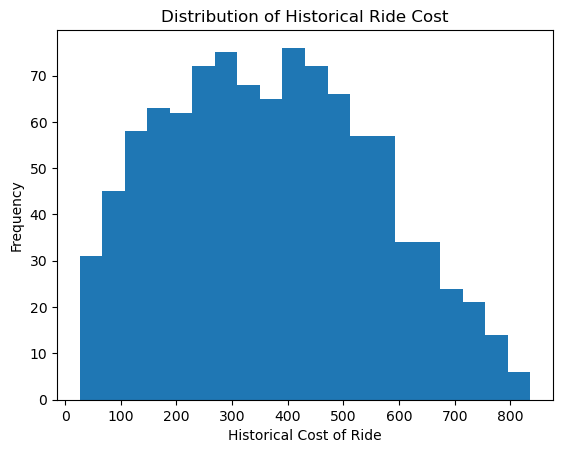

In [392]:
plt.hist(df["Historical_Cost_of_Ride"], bins=20)

plt.title("Distribution of Historical Ride Cost")
plt.xlabel("Historical Cost of Ride")
plt.ylabel("Frequency")
plt.show()

Conclusion: 
- Historical ride cost has a mean of approximately 372.50 and a median of approximately 362.02
- The middle 50% of ride costs lie between approximately 221.37 and 510.50
- The histogram shows substantial variation in historical ride costs, with fewer observations close to the minimum and maximum values

## Average Ride Cost by Category

The main goal of this section is to compare the average historical ride cost across categorical variables to understand which groups have higher or lower ride costs

In [393]:
vehicle_summary = summarise_cost_by_category(df,"Vehicle_Type")
vehicle_summary

,count,mean,median
Vehicle_Type,,,
Economy,478,346.57,331.23
Premium,522,396.25,397.59


In [394]:
location_summary = summarise_cost_by_category(df,"Location_Category")
location_summary

,count,mean,median
Location_Category,,,
Rural,332,379.94,367.76
Suburban,322,374.32,362.70
Urban,346,363.67,359.96


In [395]:
time_summary = summarise_cost_by_category(df,"Time_of_Booking")
time_summary

,count,mean,median
Time_of_Booking,,,
Afternoon,247,380.82,387.48
Evening,231,364.25,360.71
Morning,246,378.06,382.23
Night,276,367.01,336.09


In [396]:
loyalty_summary = summarise_cost_by_category(df,"Customer_Loyalty_Status")
loyalty_summary

,count,mean,median
Customer_Loyalty_Status,,,
Gold,313,376.12,373.98
Regular,320,380.13,358.95
Silver,367,362.77,348.67


Conclusion: 
- Premium rides have a higher average historical cost than economy rides, with a difference of approximately 49.68. This is the largest difference between category means in this section
- Rural rides and afternoon bookings have the highest average costs within their respective categories
- Regular customers have a slightly higher average cost than Gold and Silver customers
- It is important to keep in mind that the differences across location, booking time, and loyalty status are smaller than the difference between vehicle types

These results are descriptive and may also reflect differences in ride duration or other ride characteristics

## Average Ride Cost by Vehicle Type

The main goal of this section is to create a bar chart to compare the average historical ride cost between vehicle types

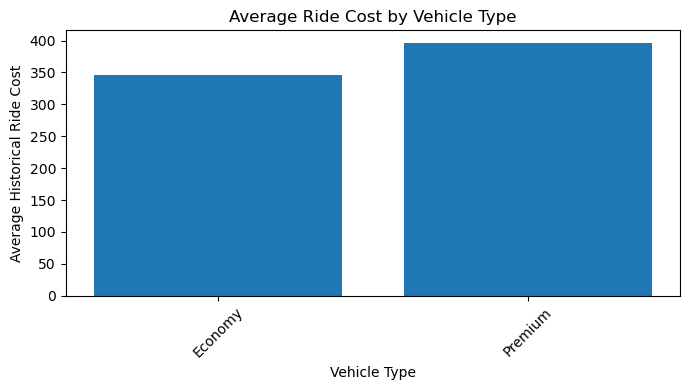

In [397]:
vehicle_cost = df.groupby("Vehicle_Type")["Historical_Cost_of_Ride"].mean().round(2)

plot_bar_chart(
    vehicle_cost, "Average Ride Cost by Vehicle Type", "Vehicle Type", "Average Historical Ride Cost"
)



Conclusion: 
- Premium rides have a higher average historical cost than economy rides. The difference is approximately 49.68, making vehicle type the categorical variable with the largest difference between group means in this analysis

## Average Ride Cost by Location Category

The main goal of this section is to create a bar chart to compare the average historical ride cost across location categories

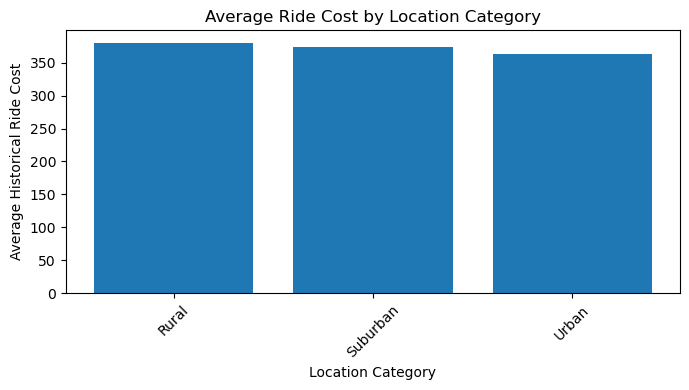

In [398]:
location_cost = (df.groupby("Location_Category")["Historical_Cost_of_Ride"].mean().round(2))

plot_bar_chart(location_cost,"Average Ride Cost by Location Category","Location Category","Average Historical Ride Cost")

Conclusion:
- Rural rides have the highest average historical cost, followed by suburban and urban rides. However, the differences between the location categories are relatively small and may also reflect differences in ride duration or other ride characteristics

## Average Ride Cost by Time of Booking

The main goal of this section is to create a bar chart to compare the average historical ride cost across different booking times

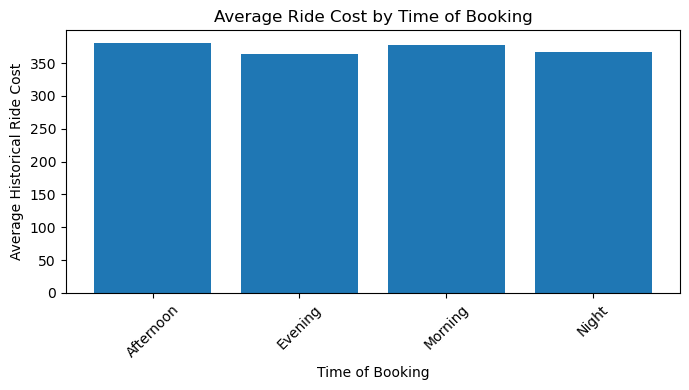

In [399]:
time_cost = df.groupby("Time_of_Booking")["Historical_Cost_of_Ride"].mean().round(2)


plot_bar_chart(
    time_cost, "Average Ride Cost by Time of Booking", "Time of Booking", "Average Historical Ride Cost"
)

Conclusion:
- Afternoon and morning bookings have slightly higher average historical costs than night and evening bookings. The differences are moderate, so booking time does not show as strong a descriptive relationship with cost as vehicle type

## Average Ride Cost by Customer Loyalty Status

The main goal of this section is to create a bar chart to compare the average historical ride cost across customer loyalty groups

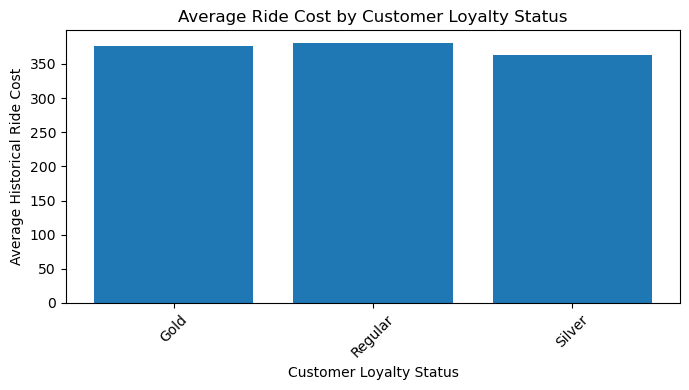

In [400]:
loyalty_cost = df.groupby("Customer_Loyalty_Status")["Historical_Cost_of_Ride"].mean().round(2)

plot_bar_chart(
    loyalty_cost, "Average Ride Cost by Customer Loyalty Status", "Customer Loyalty Status", "Average Historical Ride Cost"
)

Conclusion:
- Regular customers have the highest average historical cost, followed by Gold and Silver customers. However, the differences between loyalty groups are relatively small and do not demonstrate that loyalty status directly affects ride cost

Overall Conclusion: 
- Vehicle type shows the clearest difference in average historical ride cost, while location, booking time, and loyalty status show smaller descriptive differences

## Ride Duration and Ride Cost

The main goal of this section is to check whether longer expected ride duration is related to higher historical ride cost

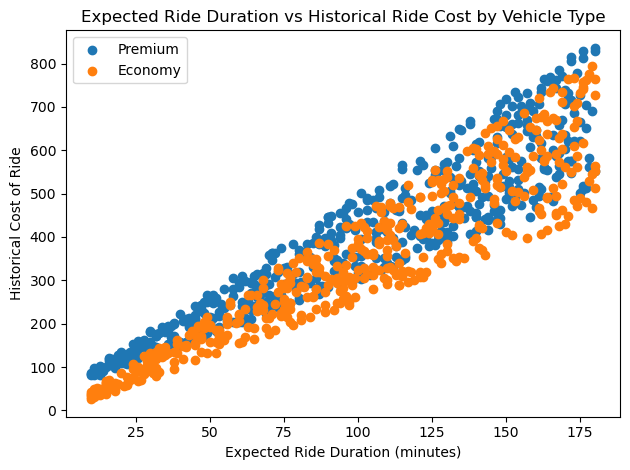

In [401]:
for vehicle_type in df["Vehicle_Type"].unique():
    vehicle_data = df[df["Vehicle_Type"] == vehicle_type]

    plt.scatter(
        vehicle_data["Expected_Ride_Duration"],
        vehicle_data["Historical_Cost_of_Ride"],
        label=vehicle_type
    )

plt.title(
    "Expected Ride Duration vs Historical Ride Cost "
    "by Vehicle Type"
)
plt.xlabel("Expected Ride Duration (minutes)")
plt.ylabel("Historical Cost of Ride")
plt.legend()
plt.tight_layout()
plt.show()

Conclusion: 

- The scatterplot shows a clear positive association between expected ride duration and historical ride cost. Longer rides generally have higher historical costs

- These results indicate that both ride duration and vehicle type are strongly associated with historical ride cost in the descriptive analysis

This suggests that expected ride duration and vehicle type are both associated with historical ride cost. Therefore, it is important to highlight that the chart shows association and does not prove causation

## Ride Cost by Duration Group and Vehicle Type

The main goal of this section is to compare vehicle types within rides of broadly similar length and, therefore, for a simple descriptive comparison, rides are divided into three groups:

- Short: 60 minutes or less
- Medium: 61–120 minutes
- Long: more than 120 minutes

In [402]:
def classify_duration(minutes):

    if minutes <= 60:
        return "Short"

    elif minutes <= 120:
        return "Medium"

    else:
        return "Long"


df["Duration_Group"] = (
    df["Expected_Ride_Duration"]
    .apply(classify_duration)
)

In [403]:
duration_vehicle_table = pd.pivot_table(
    df,
    values="Historical_Cost_of_Ride",
    index="Duration_Group",
    columns="Vehicle_Type",
    aggfunc="mean"
).round(2)

duration_vehicle_table = duration_vehicle_table.reindex(
    ["Short", "Medium", "Long"]
)

duration_vehicle_table

Vehicle_Type,Economy,Premium
Duration_Group,,
Short,118.42,170.61
Medium,314.02,357.77
Long,532.79,571.95


Conclusion:
- Average historical cost increases substantially across the short, medium and long duration groups
- Within every duration group, premium rides have a higher average cost than economy rides

Therefore, both ride duration and vehicle type show strong descriptive associations with historical ride cost

## Customer History and Ride Cost

The main goal of this section is to check whether the number of past rides is related to historical ride cost

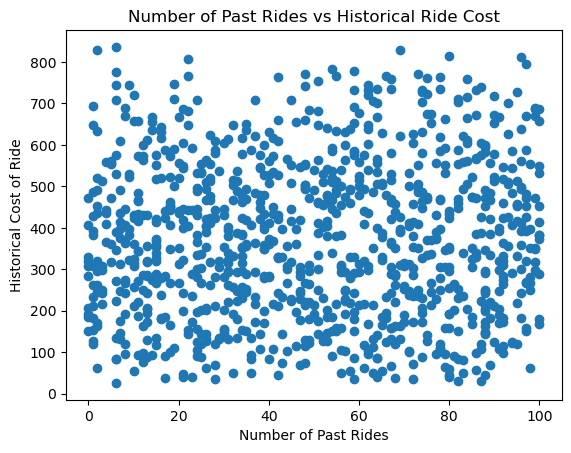

In [404]:
plt.scatter(df["Number_of_Past_Rides"], df["Historical_Cost_of_Ride"])

plt.title("Number of Past Rides vs Historical Ride Cost")
plt.xlabel("Number of Past Rides")
plt.ylabel("Historical Cost of Ride")
plt.show()

Conclusion: 
- The scatterplot does not show a clear relationship between the number of past rides and historical ride cost. However, this variable may still be useful when combined with other variables in the prediction model

## Average Ratings and Ride Cost

The main goal of this section is to check whether average customer ratings are related to historical ride cost

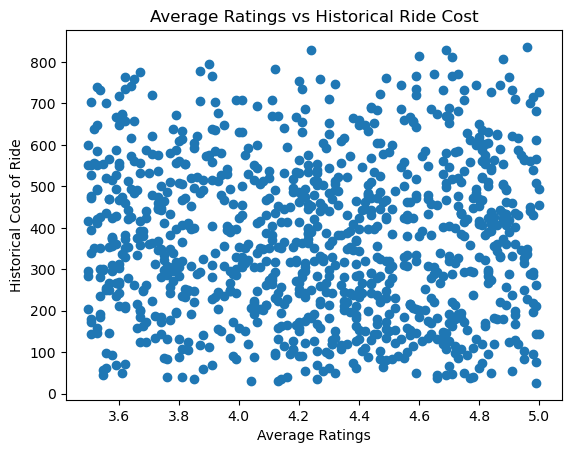

In [405]:
plt.scatter(df["Average_Ratings"], df["Historical_Cost_of_Ride"])

plt.title("Average Ratings vs Historical Ride Cost")
plt.xlabel("Average Ratings")
plt.ylabel("Historical Cost of Ride")
plt.show()

Conclusion: 

- The scatterplot does not show a clear relationship between average customer rating and historical ride cost. However, this variable may still be useful when combined with other variables during the modelling stage

## Limitations of the EDA

- The dataset does not contain a ride identifier or customer identifier, so individual rides and customers cannot be tracked across observations
- Exact dates and timestamps are not available. `Time_of_Booking` contains only broad periods such as Morning, Afternoon, Evening, and Night
- Ride distance, origin, destination, and route information are not included
- Location information is limited to Urban, Suburban, and Rural categories, so more detailed geographical patterns cannot be examined
- The fare currency is not specified
- There is no observed surge multiplier or surge-pricing indicator
- Every observation contains more riders than drivers. Therefore, balanced and supply-surplus situations cannot be compared within this dataset
- The findings describe associations in the available data and should not be interpreted as causal effects

## EDA Summary

- The cleaned dataset contains 1,000 observations and 10 original variables
- Two demand-and-supply variables were prepared for the separate demand-and-supply analysis
- Historical ride cost has a mean of approximately 372.50 and a median of approximately 362.02
- Among the variables examined in this notebook, expected ride duration shows the clearest positive relationship with historical ride cost
- Premium rides have a higher average historical cost than economy rides
- Premium rides remain more expensive within short, medium, and long duration groups
- Location, booking time, and loyalty status show smaller descriptive differences in average historical ride cost
- No clear relationship is visible between historical ride cost and either past rides or average ratings when these variables are examined separately
- The findings describe associations in the dataset and should not be interpreted as causal effects